In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rusterize as _rusterize_pkg
import seaborn as sns
import xarray as xr
from rasterix.rasterize import geometry_mask

from srm import catalog
from srm.config import _icechunk_storage_for_path
from srm.qa_flags import discover_leaves, get_data, parse_tag

In [2]:
SUMMARY_CSV = "qa_flag_summary.csv"

In [3]:
from srm.qa_flags import ATTRS_TIME_INVARIANT, ATTRS_TIME_VARYING

flag_time_invariant_name = ATTRS_TIME_INVARIANT["short_name"]
flag_time_varying_name = ATTRS_TIME_VARYING["short_name"]

# A. Define what data arrays exist to traverse

In [4]:
# --- Run parameters --------------------------------------------------------
# This regional South-Africa-box run covers three GCMs, each written to its own icechunk store
# (same bucket/branch, named by GCM the same way srm.cache.ArtifactCache names pipeline output
# stores). Looping over GCMS -- rather than hardcoding one, as this notebook used to -- is what
# lets every leaf be compared against ITS OWN GCM's catalog and lineage instead of silently
# reusing whichever GCM happened to be hardcoded.


VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]  # , "hurs"]

In [5]:
GCMS = ["CESM2-WACCM"]

BRANCH = "pr-638-global"
ROOT_DIR = "s3://carbonplan-srm/scratch/output/qa/"
STORE_SUBSET_ID = "global"

# BRANCH = "v0.13.0"
# ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
# STORE_SUBSET_ID = "global"

In [6]:
[trees, tags, _, _, _, tags_np, _, _] = discover_leaves(
    gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID
)

opened 1/1 stores on branch 'pr-638-global': CESM2-WACCM
196 leaves across 1 GCMs


/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/opt/coiled/env/lib/python3.13/site-packages/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


In [7]:
repos: dict[str, icechunk.Repository] = {}
for gcm in GCMS:
    repos[gcm] = icechunk.Repository.open(
        _icechunk_storage_for_path(f"{ROOT_DIR}{gcm}-ERA5-{STORE_SUBSET_ID}.icechunk")
    )

# B. Create CSV summarizing flag prevalence

In [8]:
ocean_mask_geoparquet = catalog.get("ocean-mask")

In [9]:
# Claude-generated patch to get the geoparquet -> gridded mask to work
_original_rusterize = _rusterize_pkg.rusterize


def _rusterize_patched(*args, **kwargs):
    if kwargs.get("res") is not None and kwargs.get("out_shape") is not None:
        kwargs = dict(kwargs)
        kwargs.pop("res")
    return _original_rusterize(*args, **kwargs)


_rusterize_pkg.rusterize = _rusterize_patched

In [10]:
tag = tags[0]
[gcm, var, scenario, ens, method] = parse_tag(tag)
target_grid_da = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_invariant_name)

# rusterize requires lat sorted descending; reorder target_grid_da first if needed
template = target_grid_da.sortby("lat", ascending=False).proj.assign_crs(spatial_ref="epsg:4326")

land_mask = ~geometry_mask(
    template,
    ocean_mask_geoparquet.to_geodataframe()[["geom"]],
    all_touched=True,
    engine="rusterize",
    xdim="lon",
    ydim="lat",
).drop_vars("spatial_ref", errors="ignore")

land_mask.load()

land_mask_u8 = land_mask.astype(np.uint8)  # 0/1, still 1 byte
n_land_time_invariant = int(land_mask_u8.sum())  # land pixel count, compute once

# time-varying: land count is per-timestep-constant since land_mask has no time dim
n_land = n_land_time_invariant

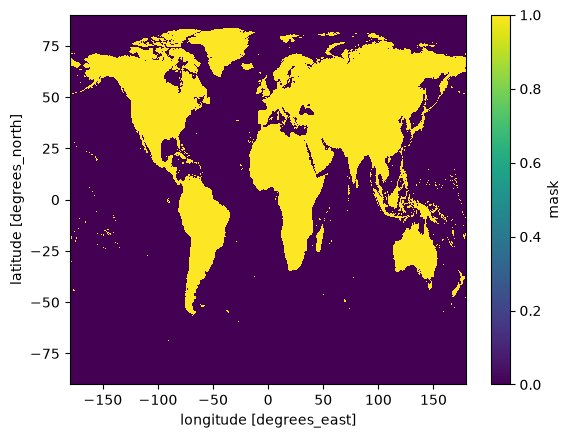

In [11]:
land_mask_u8.plot()

In [12]:
# Note none of these fractions are area-weighted

# land_mask is otherwise recomputed (full coastline rasterization) on every .where() use below
land_mask = land_mask.compute()

summary_rows = []

for i, tag in enumerate(tags):
    [gcm, var, scenario, ens, method] = parse_tag(tag)

    flag_time_varying = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_varying_name)
    flag_time_invariant = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_invariant_name)
    flag_time_varying_land = flag_time_varying * land_mask_u8
    flag_time_invariant_land = flag_time_invariant * land_mask_u8
    n_time = flag_time_varying.sizes["time"]

    # We calculate the land_frac means with sum() divided by n_land instead of
    # mean() with a mask so it goes quickly with the uint8 data type
    (
        frac_flagged_time_varying,
        frac_space_flagged_time_varying,
        frac_space_flagged_time_invariant,
        land_frac_flagged_time_varying,
        land_frac_space_flagged_time_varying,
        land_frac_space_flagged_time_invariant,
    ) = dask.compute(
        np.nanmean(flag_time_varying),
        np.nanmean(flag_time_varying.sum(dim="time") > 0),
        np.nanmean(flag_time_invariant),
        flag_time_varying_land.sum() / (n_land * n_time),
        (flag_time_varying_land.sum(dim="time") > 0).sum() / n_land,
        flag_time_invariant_land.sum() / n_land,
    )

    # Sanity check: these should each be 0 or 1
    # print(f"  check flag_time_varying max/min:   {np.nanmax(flag_time_varying)} / {np.nanmin(flag_time_varying)}")
    # print(f"  check flag_time_invariant max/min: {np.nanmax(flag_time_invariant)} / {np.nanmin(flag_time_invariant)}")

    print(f"{tag}:")
    print(
        f"  frac of dataset [time, lat, lon] flagged (time-varying):     {frac_flagged_time_varying:.4g}"
    )
    print(
        f"  frac of space [lat, lon] with >=1 flagged timestep:          {frac_space_flagged_time_varying:.4g}"
    )
    print(
        f"  frac of space [lat, lon] with time-invariant flag:           {frac_space_flagged_time_invariant:.4g}"
    )
    print(
        f"  land frac of dataset [time, lat, lon] flagged (time-varying):{land_frac_flagged_time_varying:.4g}"
    )
    print(
        f"  land frac of space [lat, lon] with >=1 flagged timestep:     {land_frac_space_flagged_time_varying:.4g}"
    )
    print(
        f"  land frac of space [lat, lon] with time-invariant flag:      {land_frac_space_flagged_time_invariant:.4g}"
    )

    summary_rows.append(
        {
            "tag": tag,
            "gcm": gcm,
            "variable": var,
            "scenario": scenario,
            "ensemble_member": ens,
            "frac_flagged_time_varying": float(frac_flagged_time_varying),
            "frac_space_flagged_time_varying": float(frac_space_flagged_time_varying),
            "frac_space_flagged_time_invariant": float(frac_space_flagged_time_invariant),
            "land_frac_flagged_time_varying": float(land_frac_flagged_time_varying),
            "land_frac_space_flagged_time_varying": float(land_frac_space_flagged_time_varying),
            "land_frac_space_flagged_time_invariant": float(land_frac_space_flagged_time_invariant),
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_CSV, index=False)
summary_df

CESM2-WACCM_pr_ssp245_001_qdmsd:
  frac of dataset [time, lat, lon] flagged (time-varying):     3.306e-06
  frac of space [lat, lon] with >=1 flagged timestep:          0.05334
  frac of space [lat, lon] with time-invariant flag:           0.2861
  land frac of dataset [time, lat, lon] flagged (time-varying):1.288e-06
  land frac of space [lat, lon] with >=1 flagged timestep:     0.02452
  land frac of space [lat, lon] with time-invariant flag:      0.3897
CESM2-WACCM_pr_ssp245_002_qdmsd:
  frac of dataset [time, lat, lon] flagged (time-varying):     1.755e-06
  frac of space [lat, lon] with >=1 flagged timestep:          0.04366
  frac of space [lat, lon] with time-invariant flag:           0.2861
  land frac of dataset [time, lat, lon] flagged (time-varying):9.99e-07
  land frac of space [lat, lon] with >=1 flagged timestep:     0.02039
  land frac of space [lat, lon] with time-invariant flag:      0.3897
CESM2-WACCM_pr_ssp245_003_qdmsd:
  frac of dataset [time, lat, lon] flagged (ti

,tag,gcm,variable,scenario,ensemble_member,frac_flagged_time_varying,frac_space_flagged_time_varying,frac_space_flagged_time_invariant,land_frac_flagged_time_varying,land_frac_space_flagged_time_varying,land_frac_space_flagged_time_invariant
0,CESM2-WACCM_pr_ssp245_001_qdmsd,CESM2-WACCM,pr,ssp245,001,0.000003,0.053338,0.286099,1.287567e-06,0.024521,0.389742
1,CESM2-WACCM_pr_ssp245_002_qdmsd,CESM2-WACCM,pr,ssp245,002,0.000002,0.043656,0.286099,9.989764e-07,0.020389,0.389742
2,CESM2-WACCM_pr_ssp245_003_qdmsd,CESM2-WACCM,pr,ssp245,003,0.000002,0.050105,0.286099,1.159063e-06,0.025296,0.389742
3,CESM2-WACCM_pr_ssp245_004_qdmsd,CESM2-WACCM,pr,ssp245,004,0.000002,0.041613,0.286099,1.216685e-06,0.024768,0.389742
4,CESM2-WACCM_pr_ssp245_005_qdmsd,CESM2-WACCM,pr,ssp245,005,0.000002,0.050709,0.286099,1.009464e-06,0.021025,0.389742
...,...,...,...,...,...,...,...,...,...,...,...
66,CESM2-WACCM_tasmax_g6_1p5k_end_002_qdmsd,CESM2-WACCM,tasmax,g6_1p5k_end,002,0.000007,0.008000,0.004403,9.998401e-07,0.001475,0.005516
67,CESM2-WACCM_pr_g6_1p5k_end_002_qdmsd,CESM2-WACCM,pr,g6_1p5k_end,002,0.000001,0.007316,0.376793,1.119616e-06,0.005247,0.500281
68,CESM2-WACCM_rsds_g6_1p5k_end_002_qdmsd,CESM2-WACCM,rsds,g6_1p5k_end,002,0.002314,0.370068,0.303537,3.295374e-03,0.338327,0.310737
69,CESM2-WACCM_tasmin_g6_1p5k_end_002_qdmsd,CESM2-WACCM,tasmin,g6_1p5k_end,002,0.000006,0.009626,0.045463,2.007943e-05,0.022773,0.020094


# C. Read in summary CSV and make summary figure

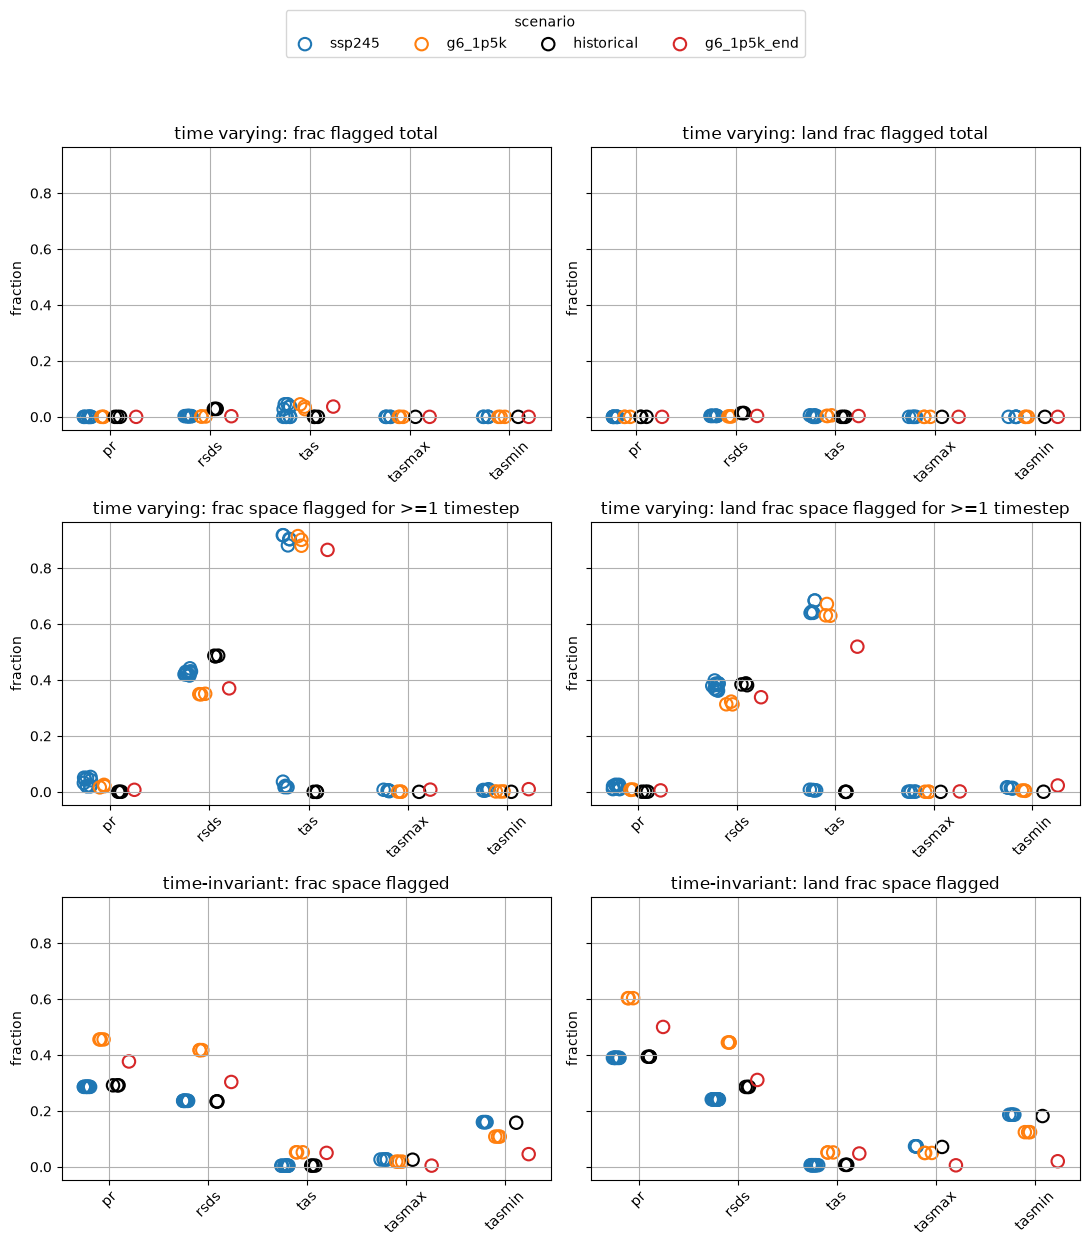

In [13]:
summary_df = pd.read_csv(SUMMARY_CSV)

metrics = [
    ("frac_flagged_time_varying", "time varying: frac flagged total"),
    ("land_frac_flagged_time_varying", "time varying: land frac flagged total"),
    ("frac_space_flagged_time_varying", "time varying: frac space flagged for >=1 timestep"),
    (
        "land_frac_space_flagged_time_varying",
        "time varying: land frac space flagged for >=1 timestep",
    ),
    ("frac_space_flagged_time_invariant", "time-invariant: frac space flagged"),
    ("land_frac_space_flagged_time_invariant", "time-invariant: land frac space flagged"),
]

VARIABLE_ORDER = ["pr", "rsds", "tas", "tasmax", "tasmin"]  # whatever order you want

variables = [v for v in VARIABLE_ORDER if v in summary_df["variable"].unique()]
scenarios = summary_df["scenario"].unique().tolist()

var_pos = {v: i for i, v in enumerate(variables)}
palette = dict(zip(scenarios, sns.color_palette(n_colors=len(scenarios))))
palette["historical"] = "black"

GROUP_SPREAD = 0.15  # distance between scenario clusters within a variable's x position
JITTER_WIDTH = 0.04  # random scatter within each scenario's own cluster

scenario_offset = {
    s: (i - (len(scenarios) - 1) / 2) * GROUP_SPREAD for i, s in enumerate(scenarios)
}

rng = np.random.default_rng(0)

fig, axes = plt.subplots(3, 2, figsize=(11, 12), sharey=True)
axes = axes.flatten()

for ax, (col, label) in zip(axes, metrics):
    for s in scenarios:
        sub = summary_df[summary_df["scenario"] == s]
        x = (
            sub["variable"].map(var_pos)
            + scenario_offset[s]
            + rng.uniform(-JITTER_WIDTH, JITTER_WIDTH, len(sub))
        )
        ax.scatter(
            x,
            sub[col],
            marker="o",
            facecolors="none",
            edgecolors=palette[s],
            linewidths=1.5,
            s=80,
            label=s,
        )
    ax.set_xticks(range(len(variables)))
    ax.set_xticklabels(variables, rotation=45)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("fraction")
    ax.grid()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="scenario",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=len(scenarios),
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# D. Evaluate flag hotspots

In [14]:
def get_data(tag, trees, var_to_analyze=None):
    [gcm, var, scenario, ens, method] = parse_tag(tag)
    if method == "no-method-specified":
        group_path = f"{scenario}/{var}/{ens}"
    else:
        group_path = f"{method}/{scenario}/{var}/{ens}"
    comparison_ds = trees[gcm][group_path]
    if var_to_analyze is None:
        var_to_analyze = var
    da = comparison_ds[var_to_analyze]

    return da

In [15]:
for i, tag in enumerate(tags):
    flag_time_varying = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_varying_name)
    flag_time_invariant = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_invariant_name)
    if i == 0:
        flag_time_invariant_cumulative = flag_time_invariant
        flag_time_varying_cumulative = flag_time_varying.sum(dim="time")
        flag_time_varying_cumulative_tseries = flag_time_varying.sum(dim=["lat","lon"])
    else:
        flag_time_invariant_cumulative = flag_time_invariant_cumulative + flag_time_invariant
        flag_time_varying_cumulative = flag_time_varying_cumulative + flag_time_varying.sum(
            dim="time"
        )
        flag_time_varying_cumulative_tseries = flag_time_varying_cumulative_tseries + flag_time_varying.sum(dim=["lat","lon"])


In [ ]:
flag_time_invariant_cumulative.load()

In [ ]:
flag_time_varying_cumulative.load()

In [26]:
for i, tag in enumerate(tags):
    flag_time_varying = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_varying_name)
    flag_time_invariant = get_data(tag=tag, trees=trees, var_to_analyze=flag_time_invariant_name)
    if i == 0:
        flag_time_varying_cumulative_tseries = flag_time_varying.sum(dim=["lat","lon"])
    else:
        flag_time_varying_cumulative_tseries = flag_time_varying_cumulative_tseries + flag_time_varying.sum(dim=["lat","lon"])


In [18]:
n_time = len(flag_time_varying["time"])
n_arrays = len(tags)

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


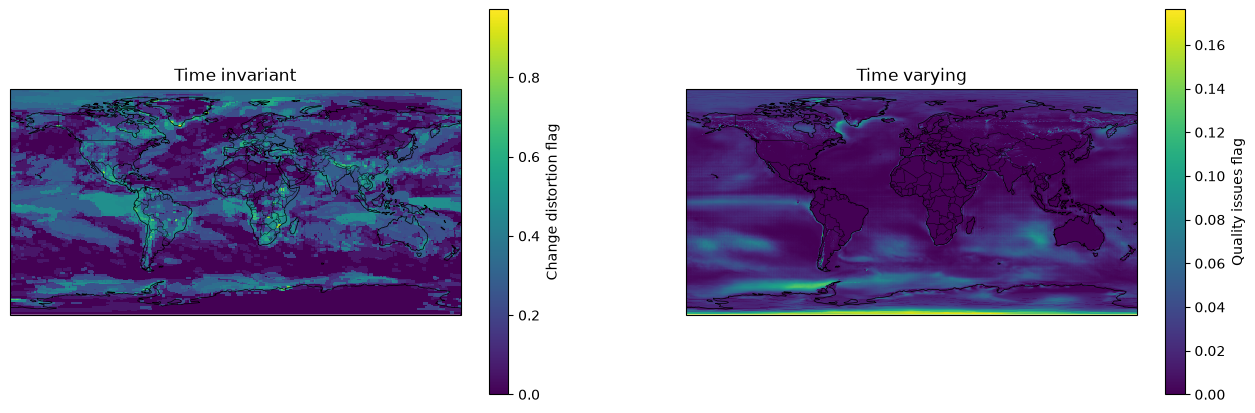

In [19]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(16, 5), subplot_kw={"projection": ccrs.PlateCarree()}
)

ax = axes[0]
(flag_time_invariant_cumulative / n_arrays).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
ax.set_title("Time invariant")

ax = axes[1]
((flag_time_varying_cumulative / n_time) / n_arrays).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
ax.set_title("Time varying")
plt.show()

# Zoom in on one example

In [22]:
tag = "CESM2-WACCM_pr_g6_1p5k_002_qdmsd"
[gcm, var, scenario, ens, method] = parse_tag(tag)
flags = xr.open_zarr(
    repos[gcm].readonly_session(BRANCH).store, group=f"{method}/{scenario}/{var}/{ens}", consolidated=False
)
flag_time_varying = flags[flag_time_varying_name]
flag_time_invariant = flags[flag_time_invariant_name]
flag_time_varying_land = flag_time_varying * land_mask_u8
flag_time_invariant_land = flag_time_invariant * land_mask_u8
n_time = flag_time_varying.sizes["time"]

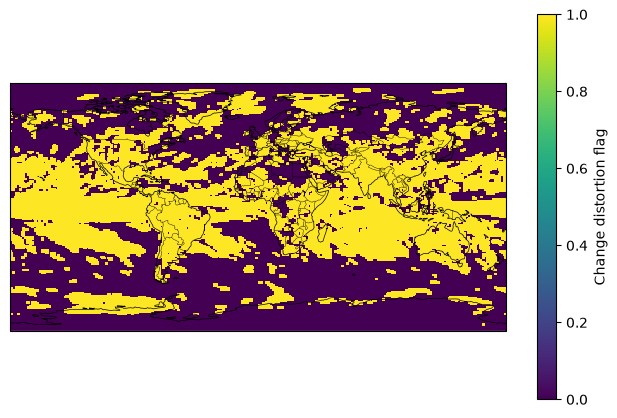

In [23]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
flag_time_invariant.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="k")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="k")
plt.show()

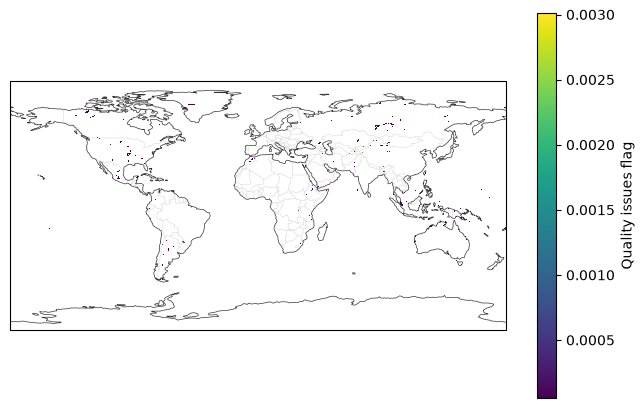

In [24]:
fig = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
freq_flagged = flag_time_varying_land.mean(dim="time")
freq_flagged.where(freq_flagged > 0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=plt.cm.viridis)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.2")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.8")
plt.show()

Text(0, 0.5, 'Fraction of land grid cells flagged in 365-day window')

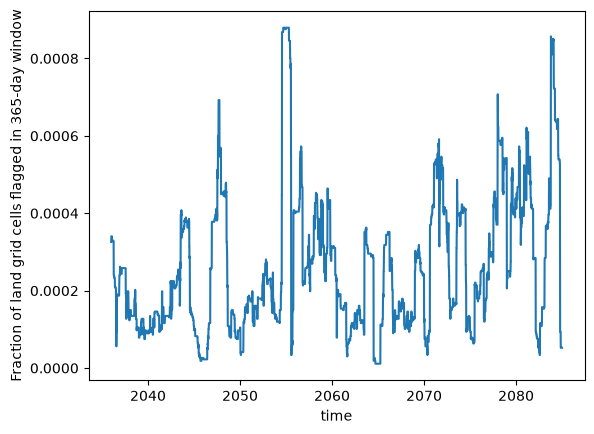

In [25]:
(flag_time_varying_land.sum(dim=["lat", "lon"]).rolling(time=365).sum() / n_land).plot()
plt.ylabel("Fraction of land grid cells flagged in 365-day window")

# Compare summary stats

In [30]:
summary_bcsd = pd.read_csv("qa_flag_summary_bcsd_v0.13.0.csv")

In [29]:
summary_qdmsd = pd.read_csv("qa_flag_summary_qdmsd.csv")

In [34]:
summary_qdmsd['tag'].split('_qdmsd')[0]

AttributeError: 'Series' object has no attribute 'split'

In [31]:
summary_bcsd

,tag,gcm,variable,scenario,ensemble_member,frac_flagged_time_varying,frac_space_flagged_time_varying,frac_space_flagged_time_invariant,land_frac_flagged_time_varying,land_frac_space_flagged_time_varying,land_frac_space_flagged_time_invariant
0,CESM2-WACCM_pr_g6_1p5k_002,CESM2-WACCM,pr,g6_1p5k,002,8.090130e-08,0.000493,0.574821,3.002127e-07,0.001894,0.727320
1,CESM2-WACCM_pr_g6_1p5k_003,CESM2-WACCM,pr,g6_1p5k,003,7.768423e-08,0.000479,0.574821,2.887370e-07,0.001815,0.727320
2,CESM2-WACCM_rsds_g6_1p5k_002,CESM2-WACCM,rsds,g6_1p5k,002,2.351584e-02,0.350506,0.624973,8.525481e-03,0.232803,0.720243
3,CESM2-WACCM_rsds_g6_1p5k_003,CESM2-WACCM,rsds,g6_1p5k,003,2.353456e-02,0.353095,0.624973,8.538522e-03,0.236205,0.720243
4,CESM2-WACCM_tas_g6_1p5k_002,CESM2-WACCM,tas,g6_1p5k,002,8.019258e-02,0.970797,0.065363,2.643127e-02,0.886984,0.095857
5,CESM2-WACCM_tas_g6_1p5k_003,CESM2-WACCM,tas,g6_1p5k,003,8.178404e-02,0.972532,0.065363,2.561686e-02,0.893421,0.095857
6,CESM2-WACCM_tasmax_g6_1p5k_002,CESM2-WACCM,tasmax,g6_1p5k,002,3.983610e-02,0.867840,0.019957,2.018254e-02,0.791153,0.039805
7,CESM2-WACCM_tasmax_g6_1p5k_003,CESM2-WACCM,tasmax,g6_1p5k,003,2.984663e-02,0.856465,0.019957,1.591354e-02,0.761999,0.039805
8,CESM2-WACCM_tasmin_g6_1p5k_002,CESM2-WACCM,tasmin,g6_1p5k,002,4.035693e-02,0.943152,0.126466,6.249800e-03,0.780932,0.107163
9,CESM2-WACCM_tasmin_g6_1p5k_003,CESM2-WACCM,tasmin,g6_1p5k,003,5.193795e-02,0.952370,0.126466,9.704653e-03,0.815131,0.107163
